In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import the dataset

In [3]:
df=pd.read_csv("healthcare-dataset-stroke-data.csv")

Performing EDA

In [4]:
df.head(30)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


Perform data preprocessing

In [5]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
df['bmi']=df['bmi'].fillna(df['bmi'].mean())
df.head(30)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.000000,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.400000,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.800000,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.893237,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.200000,Unknown,1


In [7]:
df['gender'].unique()

<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

In [8]:
Q1=df['age'].quantile(0.25)
Q3=df['age'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
outliers=df[(df['age']<lower_limit) | (df['age']>upper_limit)]
print("Number of outliers in age column:", outliers.shape[0])
outliers.head()

Number of outliers in age column: 0


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [9]:
Q1=df['avg_glucose_level'].quantile(0.25)
Q3=df['avg_glucose_level'].quantile(0.75)   
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
outliers=df[(df['avg_glucose_level']<lower_limit) | (df['avg_glucose_level']>upper_limit)]
print("Number of outliers in avg_glucose_level column:", outliers.shape[0])
outliers.head() 

Number of outliers in avg_glucose_level column: 627


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.000000,formerly smoked,1


In [10]:
df['avg_glucose_level'] = df['avg_glucose_level'].clip(lower_limit, upper_limit)

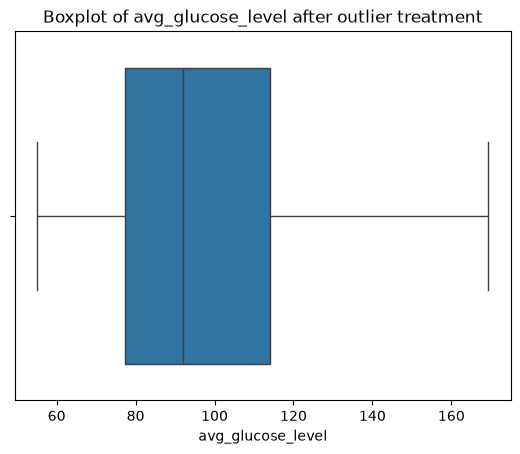

In [11]:
sns.boxplot(x=df['avg_glucose_level'])
plt.title('Boxplot of avg_glucose_level after outlier treatment')
plt.show()

In [12]:
Q1=df['bmi'].quantile(0.25)
Q3=df['bmi'].quantile(0.75)   
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
outliers=df[(df['bmi']<lower_limit) | (df['bmi']>upper_limit)]
print("Number of outliers in bmi column:", outliers.shape[0])
outliers.head() 

Number of outliers in bmi column: 126


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
21,13861,Female,52.0,1,0,Yes,Self-employed,Urban,169.3575,48.9,never smoked,1
66,17004,Female,70.0,0,0,Yes,Private,Urban,169.3575,47.5,never smoked,1
113,41069,Female,45.0,0,0,Yes,Private,Rural,169.3575,56.6,never smoked,1
254,32257,Female,47.0,0,0,Yes,Private,Urban,169.3575,50.1,Unknown,0
258,28674,Female,74.0,1,0,Yes,Self-employed,Urban,169.3575,54.6,never smoked,0


In [13]:
df['bmi']=df['bmi'].clip(lower_limit, upper_limit)

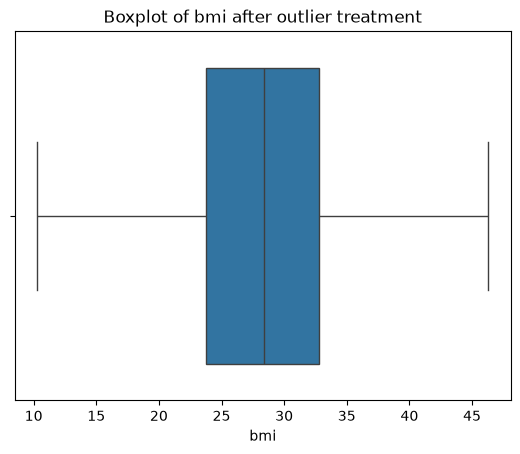

In [14]:
sns.boxplot(x=df['bmi'])
plt.title('Boxplot of bmi after outlier treatment')
plt.show()

In [15]:
df['stroke'].unique()

array([1, 0])

In [16]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.7500,28.893237,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.2000,40.000000,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.9900,30.600000,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.2900,25.600000,formerly smoked,0


In [17]:
df['ever_married'].unique()


<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [18]:
df['work_type'].unique()


<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str

In [19]:
df['Residence_type'].unique()


<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str

In [20]:
df['smoking_status'].unique()

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [21]:
df['stroke'].unique()

array([1, 0])

Now Perform a Feature Engineering

In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
le=LabelEncoder()

In [24]:

le.fit(df['Residence_type'])
print("Residence Type Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
df['Residence_type']=le.transform(df['Residence_type']) 


le.fit(df['ever_married'])

print("Ever Married Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
df['ever_married']=le.transform(df['ever_married'])

Residence Type Mapping: {'Rural': np.int64(0), 'Urban': np.int64(1)}
Ever Married Mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


In [25]:
df['Residence_type'].unique()

df['ever_married'].unique()

array([1, 0])

In [26]:
df.head(30)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,1,Private,1,169.3575,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,1,Self-employed,0,169.3575,28.893237,never smoked,1
2,31112,Male,80.0,0,1,1,Private,0,105.9200,32.500000,never smoked,1
3,60182,Female,49.0,0,0,1,Private,1,169.3575,34.400000,smokes,1
4,1665,Female,79.0,1,0,1,Self-employed,0,169.3575,24.000000,never smoked,1
5,56669,Male,81.0,0,0,1,Private,1,169.3575,29.000000,formerly smoked,1
6,53882,Male,74.0,1,1,1,Private,0,70.0900,27.400000,never smoked,1
7,10434,Female,69.0,0,0,0,Private,1,94.3900,22.800000,never smoked,1
8,27419,Female,59.0,0,0,1,Private,0,76.1500,28.893237,Unknown,1
9,60491,Female,78.0,0,0,1,Private,1,58.5700,24.200000,Unknown,1


Perform a one hot encoding

In [27]:
df=pd.get_dummies(df, columns=['gender', 'work_type', 'smoking_status'], drop_first=True,dtype=int)

In [28]:
df

,id,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,1,1,169.3575,36.600000,1,1,0,0,1,0,0,1,0,0
1,51676,61.0,0,0,1,0,169.3575,28.893237,1,0,0,0,0,1,0,0,1,0
2,31112,80.0,0,1,1,0,105.9200,32.500000,1,1,0,0,1,0,0,0,1,0
3,60182,49.0,0,0,1,1,169.3575,34.400000,1,0,0,0,1,0,0,0,0,1
4,1665,79.0,1,0,1,0,169.3575,24.000000,1,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,1,1,83.7500,28.893237,0,0,0,0,1,0,0,0,1,0
5106,44873,81.0,0,0,1,1,125.2000,40.000000,0,0,0,0,0,1,0,0,1,0
5107,19723,35.0,0,0,1,0,82.9900,30.600000,0,0,0,0,0,1,0,0,1,0
5108,37544,51.0,0,0,1,0,166.2900,25.600000,0,1,0,0,1,0,0,1,0,0


Now we drop the column of drop becaus it is not predicting about the stroke

In [29]:
df.drop('id', axis=1, inplace=True)

In [30]:
df

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,1,169.3575,36.600000,1,1,0,0,1,0,0,1,0,0
1,61.0,0,0,1,0,169.3575,28.893237,1,0,0,0,0,1,0,0,1,0
2,80.0,0,1,1,0,105.9200,32.500000,1,1,0,0,1,0,0,0,1,0
3,49.0,0,0,1,1,169.3575,34.400000,1,0,0,0,1,0,0,0,0,1
4,79.0,1,0,1,0,169.3575,24.000000,1,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,80.0,1,0,1,1,83.7500,28.893237,0,0,0,0,1,0,0,0,1,0
5106,81.0,0,0,1,1,125.2000,40.000000,0,0,0,0,0,1,0,0,1,0
5107,35.0,0,0,1,0,82.9900,30.600000,0,0,0,0,0,1,0,0,1,0
5108,51.0,0,0,1,0,166.2900,25.600000,0,1,0,0,1,0,0,1,0,0


Perform a train test

In [31]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [32]:
(df['stroke'].value_counts(normalize=True))*100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [33]:
X = df.drop('stroke', axis=1)

y = df['stroke']

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Now perform feature scaling


In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()

In [38]:
numerical_columns = ['age', 'avg_glucose_level', 'bmi']
X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)
X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [39]:
X_train[numerical_columns].describe()

,age,avg_glucose_level,bmi
count,4.088000e+03,4.088000e+03,4.088000e+03
mean,-1.564306e-17,-1.790262e-16,4.002017e-16
std,1.000122e+00,1.000122e+00,1.000122e+00
min,-1.915251e+00,-1.384629e+00,-2.584182e+00
25%,-7.680467e-01,-7.173084e-01,-6.921897e-01
50%,7.288256e-02,-2.773142e-01,-4.751067e-02
75%,7.810336e-01,3.918109e-01,5.691388e-01
max,1.710482e+00,2.050453e+00,2.461132e+00


Now performing a SMOTE

In [40]:
from imblearn.over_sampling import SMOTE

In [41]:
smote = SMOTE(random_state=42)

In [42]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

stroke
0    3889
1     199
Name: count, dtype: int64
stroke
0    3889
1    3889
Name: count, dtype: int64


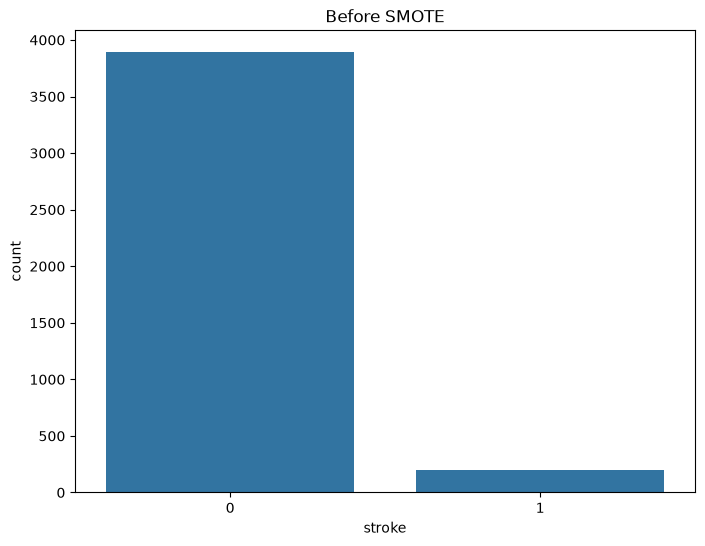

In [43]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train)

plt.title("Before SMOTE")
plt.show()

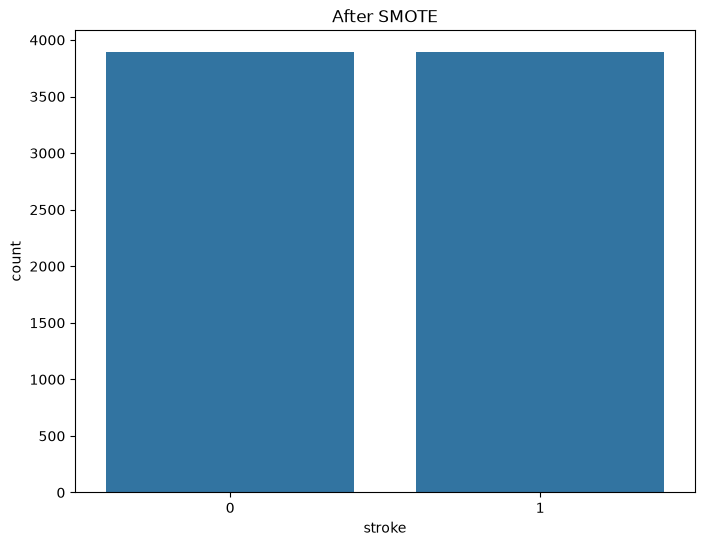

In [44]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_smote)

plt.title("After SMOTE")
plt.show()

Now perform a logistic regression

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [47]:
y_pred_log=log_model.predict(X_test)
y_pred_log

array([0, 0, 0, ..., 0, 0, 0], shape=(1022,))

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.7671232876712328
Precision: 0.14661654135338345
Recall: 0.78
F1 Score: 0.2468354430379747


In [50]:
cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[745 227]
 [ 11  39]]


In [51]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.99      0.77      0.86       972
           1       0.15      0.78      0.25        50

    accuracy                           0.77      1022
   macro avg       0.57      0.77      0.55      1022
weighted avg       0.94      0.77      0.83      1022



In [52]:
log_model.fit(X_train_smote, y_train_smote)
y_pred_log = log_model.predict(X_test)

Now perform RandomForest

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
rf_model = RandomForestClassifier(random_state=42)

In [55]:
rf_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [56]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [57]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8864970645792564
Precision: 0.06578947368421052
Recall   : 0.1
F1 Score : 0.07936507936507936
ROC-AUC  : 0.7646707818930041


In [58]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[901  71]
 [ 45   5]]


In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       972
           1       0.07      0.10      0.08        50

    accuracy                           0.89      1022
   macro avg       0.51      0.51      0.51      1022
weighted avg       0.91      0.89      0.90      1022



MLP_Classifier

In [60]:
from sklearn.neural_network import MLPClassifier

In [61]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

In [62]:
mlp_model.fit(X_train_smote, y_train_smote)
y_pred_mlp = mlp_model.predict(X_test)
y_prob_mlp = mlp_model.predict_proba(X_test)[:,1]

c:\Users\LENOVO\OneDrive\Desktop\Ai&Machine_Learning_internship\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [63]:
print("Accuracy :", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall   :", recall_score(y_test, y_pred_mlp))
print("F1 Score :", f1_score(y_test, y_pred_mlp))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_mlp))

Accuracy : 0.8688845401174168
Precision: 0.125
Recall   : 0.28
F1 Score : 0.1728395061728395
ROC-AUC  : 0.7634773662551441


In [64]:
print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       972
           1       0.12      0.28      0.17        50

    accuracy                           0.87      1022
   macro avg       0.54      0.59      0.55      1022
weighted avg       0.92      0.87      0.89      1022



Three machine learning models were trained and evaluated: Logistic Regression, Random Forest, and MLPClassifier. Although Random Forest achieved the highest accuracy, Logistic Regression achieved the highest Recall (0.78) and F1-score (0.25), making it the preferred model for this imbalanced medical classification task. In healthcare applications, detecting as many true stroke cases as possible is more important than maximizing overall accuracy.

Now perform the Hyperparameters Tuning

In [65]:
log_model = LogisticRegression(random_state=42)

In [66]:
from sklearn.model_selection import GridSearchCV

In [67]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

In [68]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [69]:
grid_search.fit(X_train_smote, y_train_smote)

c:\Users\LENOVO\OneDrive\Desktop\Ai&Machine_Learning_internship\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [70]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [71]:
print("Best Cross Validation F1 Score:", grid_search.best_score_)

Best Cross Validation F1 Score: 0.8062769366247693


In [72]:
best_model = grid_search.best_estimator_

In [73]:
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

In [74]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

Accuracy : 0.7661448140900196
Precision: 0.14606741573033707
Recall   : 0.78
F1 Score : 0.24605678233438485
ROC-AUC  : 0.824917695473251


Now perform SHAP

In [77]:
import numpy as np
print(np.__version__)

2.5.0


In [79]:
import sys
print(sys.version)

3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


In [80]:
import importlib.metadata
print(importlib.metadata.version("shap"))

0.52.0


In [81]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_model.coef_[0]
})

feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Coefficient,Importance
12,work_type_children,-2.335309,2.335309
0,age,2.317916,2.317916
11,work_type_Self-employed,-1.139540,1.139540
14,smoking_status_never smoked,-1.075184,1.075184
13,smoking_status_formerly smoked,-0.730677,0.730677
3,ever_married,-0.628898,0.628898
10,work_type_Private,-0.552625,0.552625
15,smoking_status_smokes,-0.541375,0.541375
7,gender_Male,-0.491487,0.491487
2,heart_disease,-0.478934,0.478934


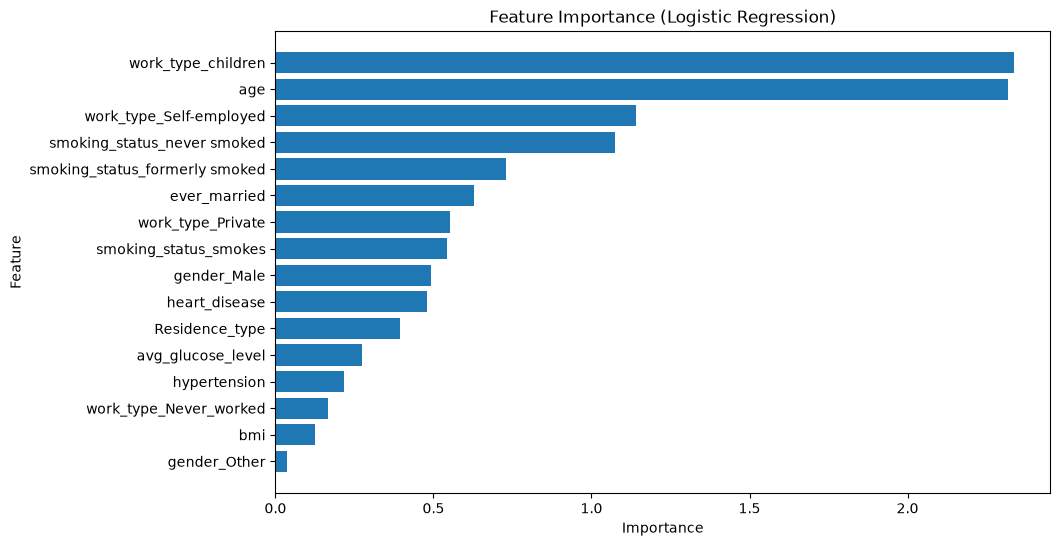

In [82]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()